# Notebook 04 — Baseline Model Evaluation

**Training is done via the CLI script — this notebook is evaluation-only.**

```bash
# Train ResNet50 (default)
python -m src.train.train_baseline --config configs/baseline.yaml

# Train ViT
python -m src.train.train_baseline --config configs/baseline.yaml --model vit_base_patch16_224
```

After training, run all cells below to get full metrics and plots for **train / val / test**.

In [36]:
import sys, json, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
from scipy.special import expit

# ── project root on path ─────────────────────────────────────────────────
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils.metrics import compute_metrics, compute_per_institution_metrics, compute_ece
from src.utils.visualization import (
    plot_confusion_matrix, plot_roc_curve, plot_pr_curve,
    plot_calibration_curve, plot_per_institution_metrics,
    plot_score_distribution,
)

# ── paths ─────────────────────────────────────────────────────────────────
CKPT_DIR  = ROOT / 'checkpoints' / 'baseline'
LOG_DIR   = ROOT / 'logs'        / 'baseline'
PLOTS_DIR = ROOT / 'plots'       / 'baseline'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Primary model to evaluate
PRIMARY_MODEL = 'resnet50'  # change to 'vit_base_patch16_224' if needed ['resnet50', 'vit_base_patch16_224']

CKPT_PATH = CKPT_DIR / f'best_{PRIMARY_MODEL}.pt'
CAL_PATH  = CKPT_DIR / f'calibrator_{PRIMARY_MODEL}.pkl'

print(f'ROOT      : {ROOT}')
print(f'Checkpoint: {CKPT_PATH}  exists={CKPT_PATH.exists()}')
print(f'Calibrator: {CAL_PATH}   exists={CAL_PATH.exists()}')

ROOT      : /Users/idan/projects/sandbox/for_tal
Checkpoint: /Users/idan/projects/sandbox/for_tal/checkpoints/baseline/best_resnet50.pt  exists=True
Calibrator: /Users/idan/projects/sandbox/for_tal/checkpoints/baseline/calibrator_resnet50.pkl   exists=True


## 1. Training History — Loss & F1 Curves

  Loaded 30 log entries from baseline_resnet50.json


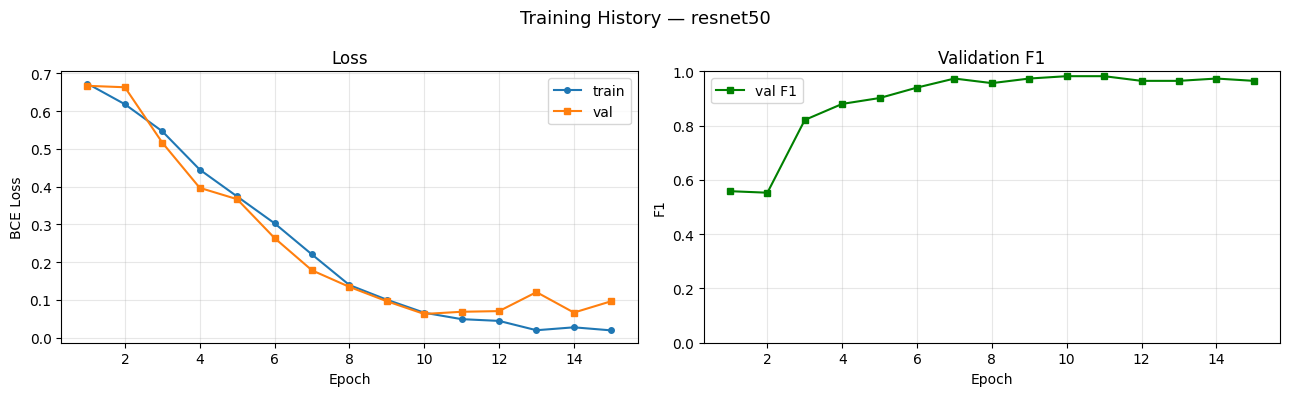

Saved → /Users/idan/projects/sandbox/for_tal/plots/baseline/training_curves_resnet50.png


In [37]:
def load_training_log(model_name: str) -> pd.DataFrame | None:
    """Load the JSON training log for a model; return DataFrame or None."""
    log_path = LOG_DIR / f'baseline_{model_name.replace("/", "_")}.json'
    if not log_path.exists():
        print(f'  No log found at {log_path}')
        return None
    with open(log_path) as f:
        records = json.load(f)
    df = pd.DataFrame(records)
    print(f'  Loaded {len(df)} log entries from {log_path.name}')
    return df


def plot_training_curves(log_df: pd.DataFrame, model_name: str) -> None:
    """Plot train/val loss and val F1 over epochs."""
    train_rows = log_df[log_df['phase'] == 'train'].sort_values('epoch')
    val_rows   = log_df[log_df['phase'] == 'val'  ].sort_values('epoch')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Training History — {model_name}', fontsize=13)

    # Loss
    ax = axes[0]
    if 'loss' in train_rows.columns:
        ax.plot(train_rows['epoch'], train_rows['loss'], label='train', marker='o', ms=4)
    if 'loss' in val_rows.columns:
        ax.plot(val_rows['epoch'], val_rows['loss'], label='val', marker='s', ms=4)
    ax.set_xlabel('Epoch');  ax.set_ylabel('BCE Loss');  ax.set_title('Loss')
    ax.legend();  ax.grid(alpha=0.3)

    # Val F1
    ax = axes[1]
    if 'f1' in val_rows.columns:
        ax.plot(val_rows['epoch'], val_rows['f1'], color='green', marker='s', ms=4, label='val F1')
    ax.set_xlabel('Epoch');  ax.set_ylabel('F1');  ax.set_title('Validation F1')
    ax.set_ylim([0, 1]);  ax.legend();  ax.grid(alpha=0.3)

    plt.tight_layout()
    out = PLOTS_DIR / f'training_curves_{model_name.replace("/", "_")}.png'
    fig.savefig(out, dpi=150);  plt.show();  print(f'Saved → {out}')


log_df = load_training_log(PRIMARY_MODEL)
if log_df is not None:
    plot_training_curves(log_df, PRIMARY_MODEL)
else:
    print('Run train_baseline.py first to generate training logs.')

## 2. Load Checkpoint — Pre-computed Logits & Calibrator

In [38]:
assert CKPT_PATH.exists(), (
    f'Checkpoint not found: {CKPT_PATH}\n'
    f'Run: python -m src.train.train_baseline --config configs/baseline.yaml'
)

ckpt = torch.load(CKPT_PATH, map_location='cpu',weights_only=False)
print(f'Checkpoint keys : {list(ckpt.keys())}')
print(f'Best epoch      : {ckpt.get("epoch")}')
print(f'Val F1          : {ckpt.get("val_f1", "n/a"):.4f}')
print(f'Temperature     : {ckpt.get("temperature", "n/a")}')
print(f'Thresholds      : {ckpt.get("thresholds")}')

# Extract splits ─────────────────────────────────────────────────────────
train_logits = np.asarray(ckpt['train_logits'], dtype=np.float32)
train_labels = np.asarray(ckpt['train_labels'], dtype=np.float32)
val_logits   = np.asarray(ckpt['val_logits'],   dtype=np.float32)
val_labels   = np.asarray(ckpt['val_labels'],   dtype=np.float32)
test_logits  = np.asarray(ckpt['test_logits'],  dtype=np.float32)
test_labels  = np.asarray(ckpt['test_labels'],  dtype=np.float32)
thresholds   = ckpt['thresholds']         # {'T_low': ..., 'T_high': ...}
temperature  = float(ckpt.get('temperature', 1.0))

print(f'\nSplit sizes — train: {len(train_labels)}  val: {len(val_labels)}  test: {len(test_labels)}')
print(f'Thresholds  — T_low={thresholds["T_low"]:.4f}  T_high={thresholds["T_high"]:.4f}')

Checkpoint keys : ['epoch', 'model_state_dict', 'val_f1', 'metrics', 'thresholds', 'config', 'model_name', 'temperature', 'train_logits', 'train_labels', 'train_metrics', 'val_logits', 'val_labels', 'val_metrics', 'test_logits', 'test_labels', 'test_metrics']
Best epoch      : 10
Val F1          : 0.9821
Temperature     : 0.5144367520942283
Thresholds      : {'T_low': 0.8265023062499938, 'T_high': 0.9132511531249969}

Split sizes — train: 710  val: 152  test: 152
Thresholds  — T_low=0.8265  T_high=0.9133


In [39]:
# Calibrate: sigmoid(logit / T)
def calibrate(logits, temperature):
    return expit(np.asarray(logits, dtype=np.float64) / temperature).astype(np.float32)

train_probs = calibrate(train_logits, temperature)
val_probs   = calibrate(val_logits,   temperature)
test_probs  = calibrate(test_logits,  temperature)

# Uncalibrated probs (T=1) for ECE comparison
train_probs_raw = calibrate(train_logits, 1.0)
val_probs_raw   = calibrate(val_logits,   1.0)
test_probs_raw  = calibrate(test_logits,  1.0)

print('Calibrated probabilities computed.')
print(f'  Train — mean={train_probs.mean():.3f}  std={train_probs.std():.3f}')
print(f'  Val   — mean={val_probs.mean():.3f}  std={val_probs.std():.3f}')
print(f'  Test  — mean={test_probs.mean():.3f}  std={test_probs.std():.3f}')

Calibrated probabilities computed.
  Train — mean=0.375  std=0.478
  Val   — mean=0.367  std=0.471
  Test  — mean=0.373  std=0.473


## 3. Comprehensive Metrics Table — Train / Val / Test

In [40]:
metric_rows = {}
for split_name, labels, probs in [
    ('Train', train_labels, train_probs),
    ('Val',   val_labels,   val_probs),
    ('Test',  test_labels,  test_probs),
]:
    m = compute_metrics(labels, probs, thresholds)
    metric_rows[split_name] = m

metrics_df = pd.DataFrame(metric_rows).T
metrics_df.index.name = 'Split'

# Pretty-print with 4 decimal places
styled = metrics_df.style \
    .format('{:.4f}', na_rep='—') \
    .background_gradient(cmap='RdYlGn', subset=['f1', 'roc_auc', 'pr_auc', 'precision_safe', 'recall_risky']) \
    .background_gradient(cmap='RdYlGn_r', subset=['false_safe_rate', 'ece'])

print(f'\n=== Metrics — {PRIMARY_MODEL} ===')
display(styled)

# Also print as plain text
print(metrics_df.round(4).to_string())


=== Metrics — resnet50 ===


,f1,precision_safe,recall_risky,false_safe_rate,review_rate,roc_auc,pr_auc,ece
Split,,,,,,,,
Train,0.9848,0.9844,0.9662,0.0263,0.0028,0.9998,0.9997,0.0041
Val,0.9821,0.9794,0.9298,0.0351,0.0132,0.9989,0.9983,0.0186
Test,0.9730,0.9694,0.9298,0.0526,0.0066,1.0000,1.0000,0.0133


           f1  precision_safe  recall_risky  false_safe_rate  review_rate  roc_auc  pr_auc     ece
Split                                                                                             
Train  0.9848          0.9844        0.9662           0.0263       0.0028   0.9998  0.9997  0.0041
Val    0.9821          0.9794        0.9298           0.0351       0.0132   0.9989  0.9983  0.0186
Test   0.9730          0.9694        0.9298           0.0526       0.0066   1.0000  1.0000  0.0133


## 4. Calibration Analysis — ECE Before vs After Temperature Scaling

=== ECE Comparison — T=0.5144 ===


,ECE (uncalibrated),ECE (T=0.514)
Train,0.0259,0.0041
Val,0.0454,0.0186
Test,0.0376,0.0133


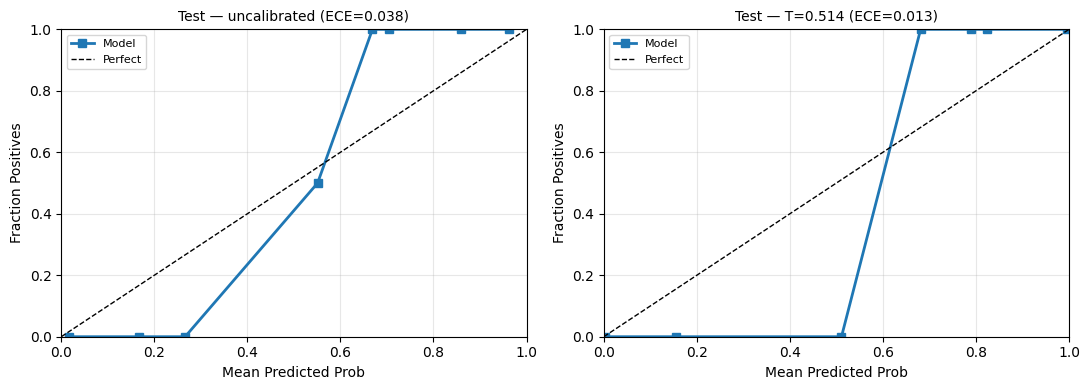

Saved → /Users/idan/projects/sandbox/for_tal/plots/baseline/calibration_resnet50.png


In [41]:
ece_table = {}
for split_name, labels, probs_raw, probs_cal in [
    ('Train', train_labels, train_probs_raw, train_probs),
    ('Val',   val_labels,   val_probs_raw,   val_probs),
    ('Test',  test_labels,  test_probs_raw,  test_probs),
]:
    ece_table[split_name] = {
        'ECE (uncalibrated)': compute_ece(labels, probs_raw),
        f'ECE (T={temperature:.3f})': compute_ece(labels, probs_cal),
    }

ece_df = pd.DataFrame(ece_table).T
print(f'=== ECE Comparison — T={temperature:.4f} ===')
display(ece_df.style.format('{:.4f}').background_gradient(cmap='RdYlGn_r'))

# Calibration curve on test set
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
from sklearn.calibration import calibration_curve
for ax, probs, title in [
    (axes[0], test_probs_raw, f'Test — uncalibrated (ECE={compute_ece(test_labels, test_probs_raw):.3f})'),
    (axes[1], test_probs,     f'Test — T={temperature:.3f} (ECE={compute_ece(test_labels, test_probs):.3f})'),
]:
    if len(np.unique(test_labels)) >= 2:
        fop, mpv = calibration_curve(test_labels, probs, n_bins=10, strategy='uniform')
        ax.plot(mpv, fop, 's-', lw=2, label='Model')
    ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect')
    ax.set_title(title, fontsize=10);  ax.set_xlabel('Mean Predicted Prob');  ax.set_ylabel('Fraction Positives')
    ax.legend(fontsize=8);  ax.set_xlim([0,1]);  ax.set_ylim([0,1]);  ax.grid(alpha=0.3)

plt.tight_layout()
out = PLOTS_DIR / f'calibration_{PRIMARY_MODEL}.png'
fig.savefig(out, dpi=150);  plt.show();  print(f'Saved → {out}')

## 5. Confusion Matrix

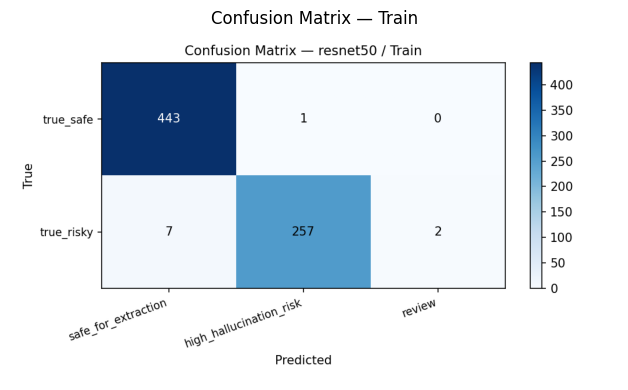

Saved → /Users/idan/projects/sandbox/for_tal/plots/baseline/confusion_resnet50_train.png


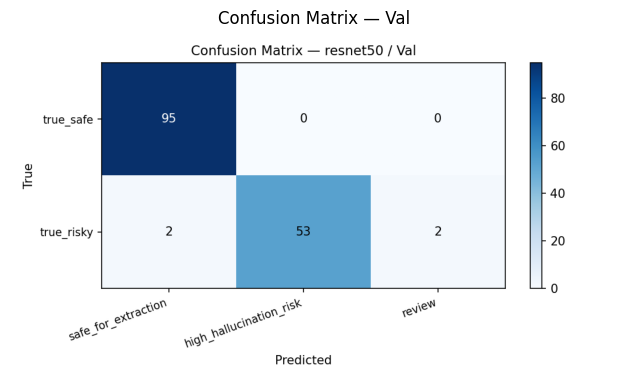

Saved → /Users/idan/projects/sandbox/for_tal/plots/baseline/confusion_resnet50_val.png


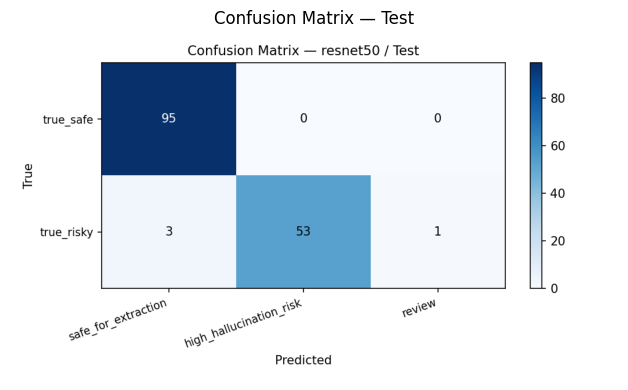

Saved → /Users/idan/projects/sandbox/for_tal/plots/baseline/confusion_resnet50_test.png


In [42]:
def apply_thresholds(probs, thresholds):
    t_low, t_high = thresholds['T_low'], thresholds['T_high']
    return np.where(probs < t_low, 0, np.where(probs > t_high, 1, 2)).astype(int)

for split_name, labels, probs in [
    ('Train', train_labels, train_probs),
    ('Val',   val_labels,   val_probs),
    ('Test',  test_labels,  test_probs),
]:
    pred_ternary = apply_thresholds(probs, thresholds)
    out = PLOTS_DIR / f'confusion_{PRIMARY_MODEL}_{split_name.lower()}.png'
    plot_confusion_matrix(
        labels, pred_ternary, str(out),
        title=f'Confusion Matrix — {PRIMARY_MODEL} / {split_name}'
    )
    img = plt.imread(str(out))
    plt.figure(figsize=(7, 4));  plt.imshow(img);  plt.axis('off')
    plt.title(f'Confusion Matrix — {split_name}');  plt.tight_layout();  plt.show()
    print(f'Saved → {out}')

## 6. ROC & PR Curves — Val vs Test

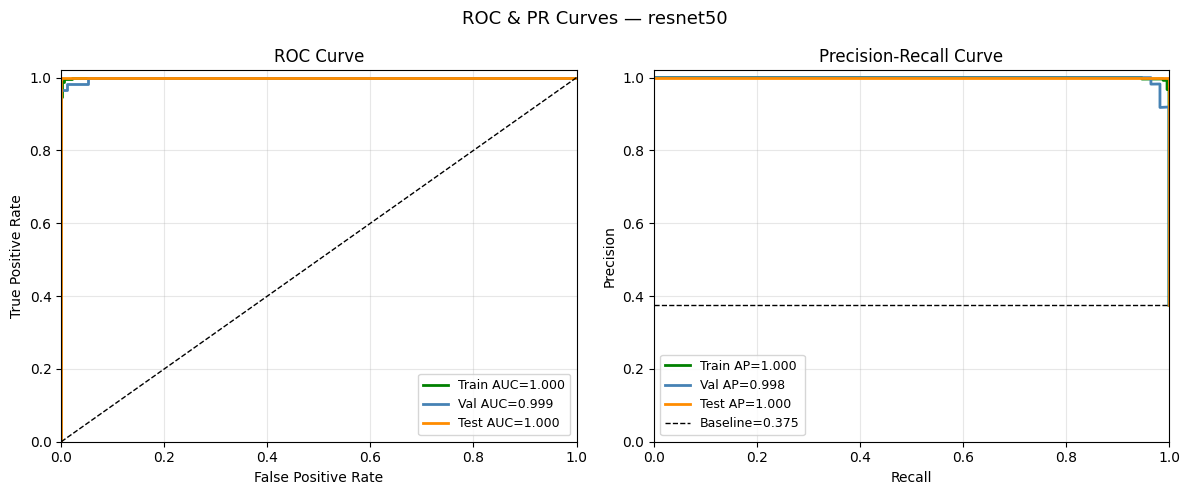

Saved → /Users/idan/projects/sandbox/for_tal/plots/baseline/roc_pr_resnet50.png


In [43]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(f'ROC & PR Curves — {PRIMARY_MODEL}', fontsize=13)

colors = {'Val': 'steelblue', 'Test': 'darkorange', 'Train': 'green'}

# ROC
ax = axes[0]
for split_name, labels, probs in [
    ('Train', train_labels, train_probs),
    ('Val',   val_labels,   val_probs),
    ('Test',  test_labels,  test_probs),
]:
    if len(np.unique(labels)) >= 2:
        fpr, tpr, _ = roc_curve(labels, probs)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, color=colors[split_name], label=f'{split_name} AUC={roc_auc:.3f}')
ax.plot([0,1],[0,1],'k--',lw=1);  ax.set_xlim([0,1]);  ax.set_ylim([0,1.02])
ax.set_xlabel('False Positive Rate');  ax.set_ylabel('True Positive Rate');  ax.set_title('ROC Curve')
ax.legend(fontsize=9);  ax.grid(alpha=0.3)

# PR
ax = axes[1]
for split_name, labels, probs in [
    ('Train', train_labels, train_probs),
    ('Val',   val_labels,   val_probs),
    ('Test',  test_labels,  test_probs),
]:
    if len(np.unique(labels)) >= 2:
        precision, recall, _ = precision_recall_curve(labels, probs)
        ap = average_precision_score(labels, probs)
        ax.plot(recall, precision, lw=2, color=colors[split_name], label=f'{split_name} AP={ap:.3f}')
baseline = test_labels.mean()
ax.axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline={baseline:.3f}')
ax.set_xlim([0,1]);  ax.set_ylim([0,1.02])
ax.set_xlabel('Recall');  ax.set_ylabel('Precision');  ax.set_title('Precision-Recall Curve')
ax.legend(fontsize=9);  ax.grid(alpha=0.3)

plt.tight_layout()
out = PLOTS_DIR / f'roc_pr_{PRIMARY_MODEL}.png'
fig.savefig(out, dpi=150);  plt.show();  print(f'Saved → {out}')

## 7. Score Distribution — All Splits

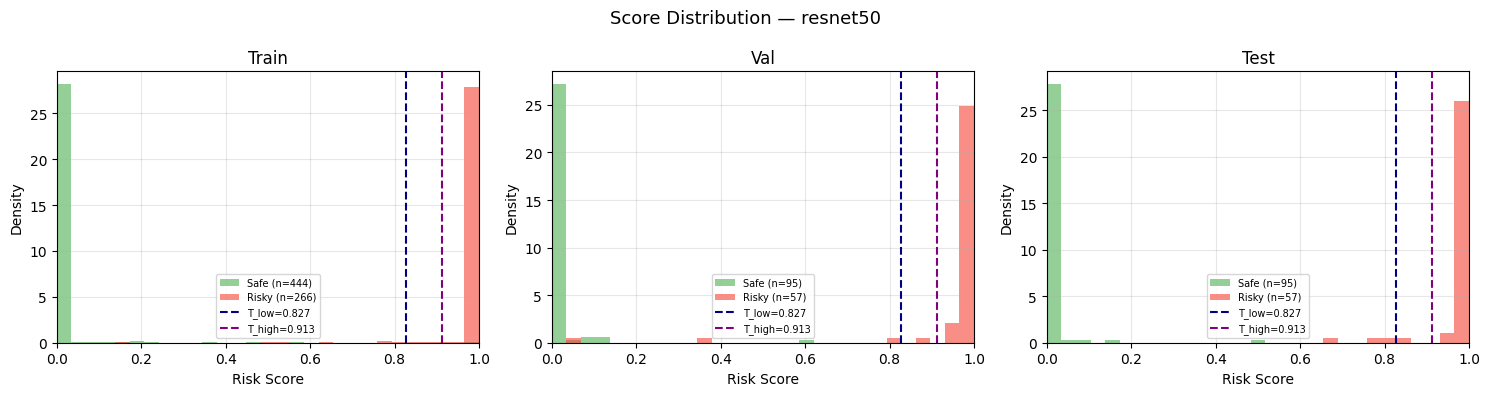

Saved → /Users/idan/projects/sandbox/for_tal/plots/baseline/score_dist_resnet50.png


In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
fig.suptitle(f'Score Distribution — {PRIMARY_MODEL}', fontsize=13)
bins = np.linspace(0, 1, 30)

for ax, split_name, labels, probs in [
    (axes[0], 'Train', train_labels, train_probs),
    (axes[1], 'Val',   val_labels,   val_probs),
    (axes[2], 'Test',  test_labels,  test_probs),
]:
    safe_sc  = probs[labels == 0]
    risky_sc = probs[labels == 1]
    if len(safe_sc)  > 0: ax.hist(safe_sc,  bins=bins, alpha=0.6, color='#4caf50', label=f'Safe (n={len(safe_sc)})',  density=True)
    if len(risky_sc) > 0: ax.hist(risky_sc, bins=bins, alpha=0.6, color='#f44336', label=f'Risky (n={len(risky_sc)})', density=True)
    t_low, t_high = thresholds['T_low'], thresholds['T_high']
    ax.axvline(t_low,  color='navy',   linestyle='--', lw=1.5, label=f'T_low={t_low:.3f}')
    ax.axvline(t_high, color='purple', linestyle='--', lw=1.5, label=f'T_high={t_high:.3f}')
    ax.set_title(split_name);  ax.set_xlabel('Risk Score');  ax.set_ylabel('Density')
    ax.legend(fontsize=7);  ax.set_xlim([0,1]);  ax.grid(alpha=0.3)

plt.tight_layout()
out = PLOTS_DIR / f'score_dist_{PRIMARY_MODEL}.png'
fig.savefig(out, dpi=150);  plt.show();  print(f'Saved → {out}')

## 8. Per-Institution Breakdown

In [45]:
import yaml
from src.data.dataset import HallucinationRiskDataset

with open(ROOT / 'configs' / 'baseline.yaml') as f:
    cfg = yaml.safe_load(f)

metadata_csv = cfg['data'].get('metadata_csv', 'data/metadata.csv')
rendered_dir = cfg['data'].get('rendered_dir', 'data/rendered_pages')

val_ds  = HallucinationRiskDataset(metadata_csv=str(ROOT/metadata_csv), split='val',  rendered_dir=str(ROOT/rendered_dir), augment=False)
test_ds = HallucinationRiskDataset(metadata_csv=str(ROOT/metadata_csv), split='test', rendered_dir=str(ROOT/rendered_dir), augment=False)

def get_institutions(ds):
    if 'institution' in ds.df.columns:
        return ds.df['institution'].values
    return np.array(['unknown'] * len(ds))

val_inst  = get_institutions(val_ds)
test_inst = get_institutions(test_ds)

per_inst_val  = compute_per_institution_metrics(val_labels,  val_probs,  val_inst,  thresholds)
per_inst_test = compute_per_institution_metrics(test_labels, test_probs, test_inst, thresholds)

print('=== Per-Institution — Val ===')
display(per_inst_val.style.format('{:.4f}', subset=per_inst_val.select_dtypes('float').columns).background_gradient(cmap='RdYlGn'))

print('\n=== Per-Institution — Test ===')
display(per_inst_test.style.format('{:.4f}', subset=per_inst_test.select_dtypes('float').columns).background_gradient(cmap='RdYlGn'))

=== Per-Institution — Val ===


,institution,n_samples,f1,recall_risky,false_safe_rate,review_rate
0,questionnaires,57,0.9821,0.9298,0.0351,0.0351
1,regular_docs,95,0.0000,nan,nan,0.0000



=== Per-Institution — Test ===


,institution,n_samples,f1,recall_risky,false_safe_rate,review_rate
0,questionnaires,57,0.9730,0.9298,0.0526,0.0175
1,regular_docs,95,0.0000,nan,nan,0.0000


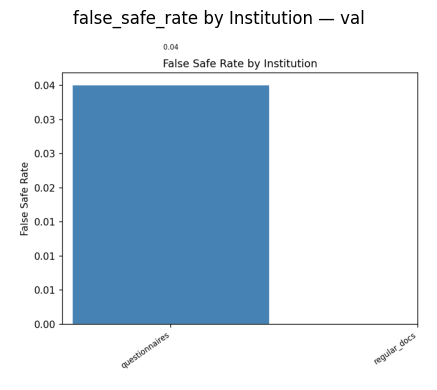

Saved → /Users/idan/projects/sandbox/for_tal/plots/baseline/per_institution_false_safe_rate_resnet50_val.png


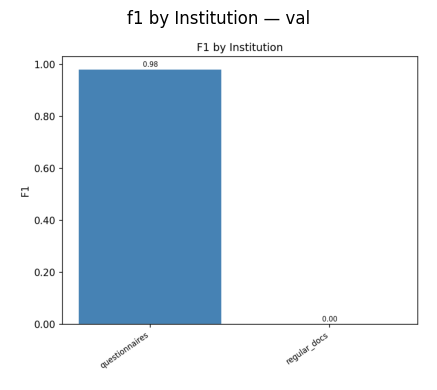

Saved → /Users/idan/projects/sandbox/for_tal/plots/baseline/per_institution_f1_resnet50_val.png


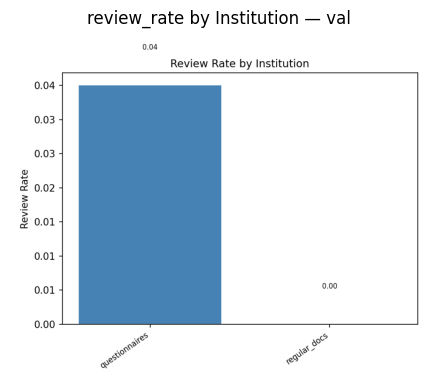

Saved → /Users/idan/projects/sandbox/for_tal/plots/baseline/per_institution_review_rate_resnet50_val.png


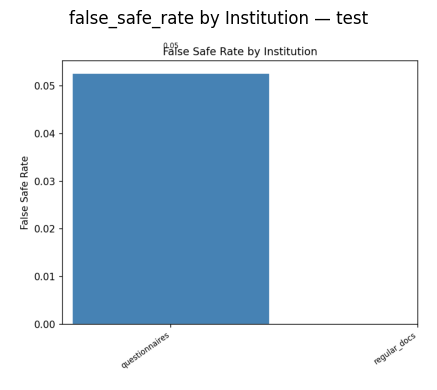

Saved → /Users/idan/projects/sandbox/for_tal/plots/baseline/per_institution_false_safe_rate_resnet50_test.png


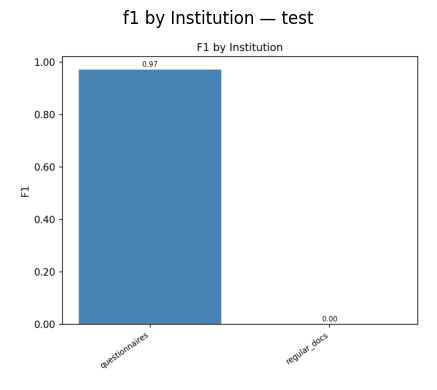

Saved → /Users/idan/projects/sandbox/for_tal/plots/baseline/per_institution_f1_resnet50_test.png


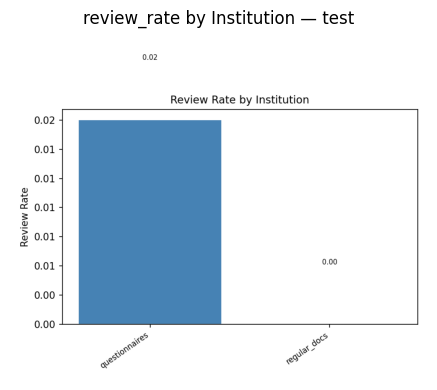

Saved → /Users/idan/projects/sandbox/for_tal/plots/baseline/per_institution_review_rate_resnet50_test.png


In [46]:
for split_name, df in [('val', per_inst_val), ('test', per_inst_test)]:
    for metric in ['false_safe_rate', 'f1', 'review_rate']:
        if metric in df.columns:
            out = PLOTS_DIR / f'per_institution_{metric}_{PRIMARY_MODEL}_{split_name}.png'
            plot_per_institution_metrics(df, metric, str(out))
            img = plt.imread(str(out))
            plt.figure(figsize=(8, 4));  plt.imshow(img);  plt.axis('off')
            plt.title(f'{metric} by Institution — {split_name}');  plt.tight_layout();  plt.show()
            print(f'Saved → {out}')

## 9. ViT Comparison (if trained)

=== Model Comparison ===


,f1,precision_safe,recall_risky,false_safe_rate,review_rate,roc_auc,pr_auc,ece
Model/Split,,,,,,,,
resnet50/Train,0.9848,0.9844,0.9662,0.0263,0.0028,0.9998,0.9997,0.0041
resnet50/Val,0.9821,0.9794,0.9298,0.0351,0.0132,0.9989,0.9983,0.0186
resnet50/Test,0.9730,0.9694,0.9298,0.0526,0.0066,1.0000,1.0000,0.0133
vit_base_patch16_224/Train,0.9650,0.9610,0.9211,0.0677,0.0042,0.9994,0.9990,0.0202
vit_base_patch16_224/Val,0.9821,0.9794,0.8772,0.0351,0.0329,0.9998,0.9997,0.0243
vit_base_patch16_224/Test,0.9643,0.9691,0.8772,0.0526,0.0263,0.9978,0.9961,0.0278


  Loaded 14 log entries from baseline_vit_base_patch16_224.json


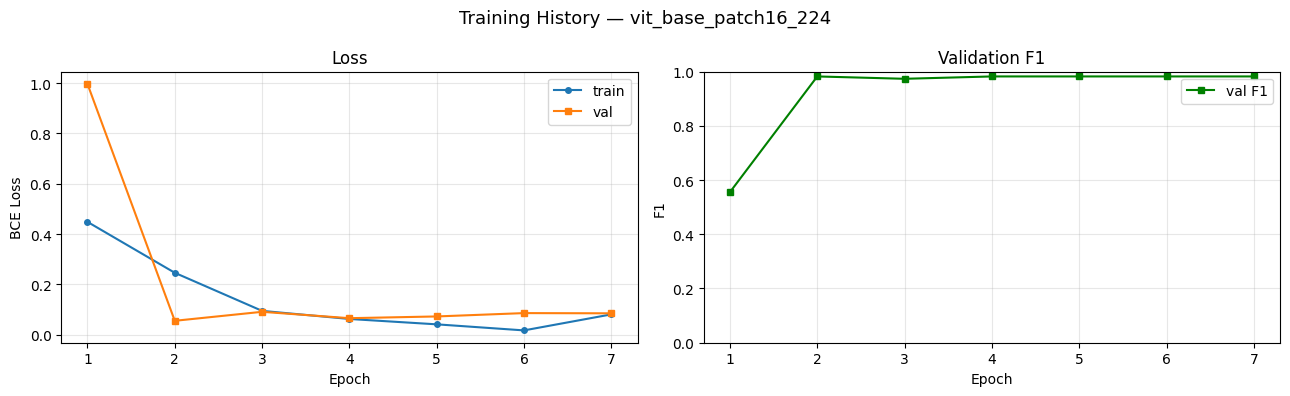

Saved → /Users/idan/projects/sandbox/for_tal/plots/baseline/training_curves_vit_base_patch16_224.png


In [47]:
VIT_NAME = 'vit_base_patch16_224'
vit_ckpt_path = CKPT_DIR / f'best_{VIT_NAME}.pt'

if vit_ckpt_path.exists():
    vit_ckpt = torch.load(vit_ckpt_path, map_location='cpu',weights_only=False)
    vit_temp = float(vit_ckpt.get('temperature', 1.0))
    vit_thresh = vit_ckpt['thresholds']

    vit_train_probs = calibrate(vit_ckpt['train_logits'], vit_temp)
    vit_val_probs   = calibrate(vit_ckpt['val_logits'],   vit_temp)
    vit_test_probs  = calibrate(vit_ckpt['test_logits'],  vit_temp)

    comparison_rows = {}
    for model_name, t_probs, v_probs, te_probs, thresh in [
        (PRIMARY_MODEL, train_probs, val_probs, test_probs, thresholds),
        (VIT_NAME,      vit_train_probs, vit_val_probs, vit_test_probs, vit_thresh),
    ]:
        for split_name, labels, probs in [
            ('Train', train_labels, t_probs),
            ('Val',   val_labels,   v_probs),
            ('Test',  test_labels,  te_probs),
        ]:
            m = compute_metrics(labels, probs, thresh)
            comparison_rows[f'{model_name}/{split_name}'] = m

    cmp_df = pd.DataFrame(comparison_rows).T
    cmp_df.index.name = 'Model/Split'
    print('=== Model Comparison ===')
    display(cmp_df.style.format('{:.4f}', na_rep='—').background_gradient(cmap='RdYlGn', subset=['f1', 'roc_auc']))

    # ViT training curves
    vit_log_df = load_training_log(VIT_NAME)
    if vit_log_df is not None:
        plot_training_curves(vit_log_df, VIT_NAME)
else:
    print(f'ViT checkpoint not found at {vit_ckpt_path}.')
    print(f'To train: python -m src.train.train_baseline --config configs/baseline.yaml --model {VIT_NAME}')

## 10. Summary Export

In [48]:
summary_rows = []
for split_name, labels, probs in [
    ('Train', train_labels, train_probs),
    ('Val',   val_labels,   val_probs),
    ('Test',  test_labels,  test_probs),
]:
    m = compute_metrics(labels, probs, thresholds)
    row = {'model': PRIMARY_MODEL, 'split': split_name, 'temperature': temperature, **m,
           'T_low': thresholds['T_low'], 'T_high': thresholds['T_high']}
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
out_csv = PLOTS_DIR / f'summary_{PRIMARY_MODEL}.csv'
summary_df.to_csv(out_csv, index=False)
print(f'Summary saved → {out_csv}')
display(summary_df.style.format('{:.4f}', subset=summary_df.select_dtypes('float').columns))

Summary saved → /Users/idan/projects/sandbox/for_tal/plots/baseline/summary_resnet50.csv


,model,split,temperature,f1,precision_safe,recall_risky,false_safe_rate,review_rate,roc_auc,pr_auc,ece,T_low,T_high
0,resnet50,Train,0.5144,0.9848,0.9844,0.9662,0.0263,0.0028,0.9998,0.9997,0.0041,0.8265,0.9133
1,resnet50,Val,0.5144,0.9821,0.9794,0.9298,0.0351,0.0132,0.9989,0.9983,0.0186,0.8265,0.9133
2,resnet50,Test,0.5144,0.9730,0.9694,0.9298,0.0526,0.0066,1.0000,1.0000,0.0133,0.8265,0.9133
